# Probability Product Kernel - KNN Classification

In [1]:

!pip install -q tensorflow tensorflow-probability scikit-learn matplotlib pandas optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.6 MB/s eta 0:00:00



PPK-KNN CLASSIFICATION — REPEATED K-FOLD CV
  Train/test split seed : 42  (fixed)
  CV base seed          : 0
  CV fold seeds         : [0, 1, 2, 3, 4]
  n_splits x n_repeats  : 7 x 5 = 35 total folds
Loading HMMs from /content/drive/MyDrive/multivariate_frontal_hmms_n5_f7.csv...


[I 2026-03-31 15:43:21,491] A new study created in memory with name: no-name-0fef056c-e9f7-4fff-a468-207fb038ca84


  Loaded 121 subjects
  ADHD: 61, Control: 60
  States: 3, Components: 3, Features: 7

  Train: 96 subjects  (ADHD: 48, Control: 48)
  Test : 25 subjects  (ADHD: 13, Control: 12)

SUBJECT ROSTER — TRAIN / TEST SPLIT

--- TRAIN SET (96 subjects) ---
  v129_preprocessed                         Control
  v113_preprocessed                         Control
  v57p_preprocessed                         Control
  v42p_preprocessed                         Control
  v151_preprocessed                         Control
  v44p_preprocessed                         Control
  v115_preprocessed                         Control
  v45p_preprocessed                         Control
  v59p_preprocessed                         Control
  v58p_preprocessed                         Control
  v41p_preprocessed                         Control
  v299_preprocessed                         Control
  v310_preprocessed                         Control
  v49p_preprocessed                         Control
  v308_preprocessed    

  0%|          | 0/3500 [00:00<?, ?it/s]

[I 2026-03-31 15:43:38,001] Trial 0 finished with value: 0.6353741496598639 and parameters: {'rho': 0.4370861069626263, 'T': 15, 'k_neighbors': 7}. Best is trial 0 with value: 0.6353741496598639.
[I 2026-03-31 15:43:45,189] Trial 1 finished with value: 0.5857142857142859 and parameters: {'rho': 0.6387926357773329, 'T': 3, 'k_neighbors': 1}. Best is trial 0 with value: 0.6353741496598639.
[I 2026-03-31 15:43:51,434] Trial 2 finished with value: 0.632312925170068 and parameters: {'rho': 0.15227525095137953, 'T': 13, 'k_neighbors': 7}. Best is trial 0 with value: 0.6353741496598639.
[I 2026-03-31 15:43:55,558] Trial 3 finished with value: 0.526530612244898 and parameters: {'rho': 0.737265320016441, 'T': 1, 'k_neighbors': 9}. Best is trial 0 with value: 0.6353741496598639.
[I 2026-03-31 15:44:00,154] Trial 4 finished with value: 0.5986394557823128 and parameters: {'rho': 0.8491983767203796, 'T': 4, 'k_neighbors': 1}. Best is trial 0 with value: 0.6353741496598639.
[I 2026-03-31 15:44:06,04

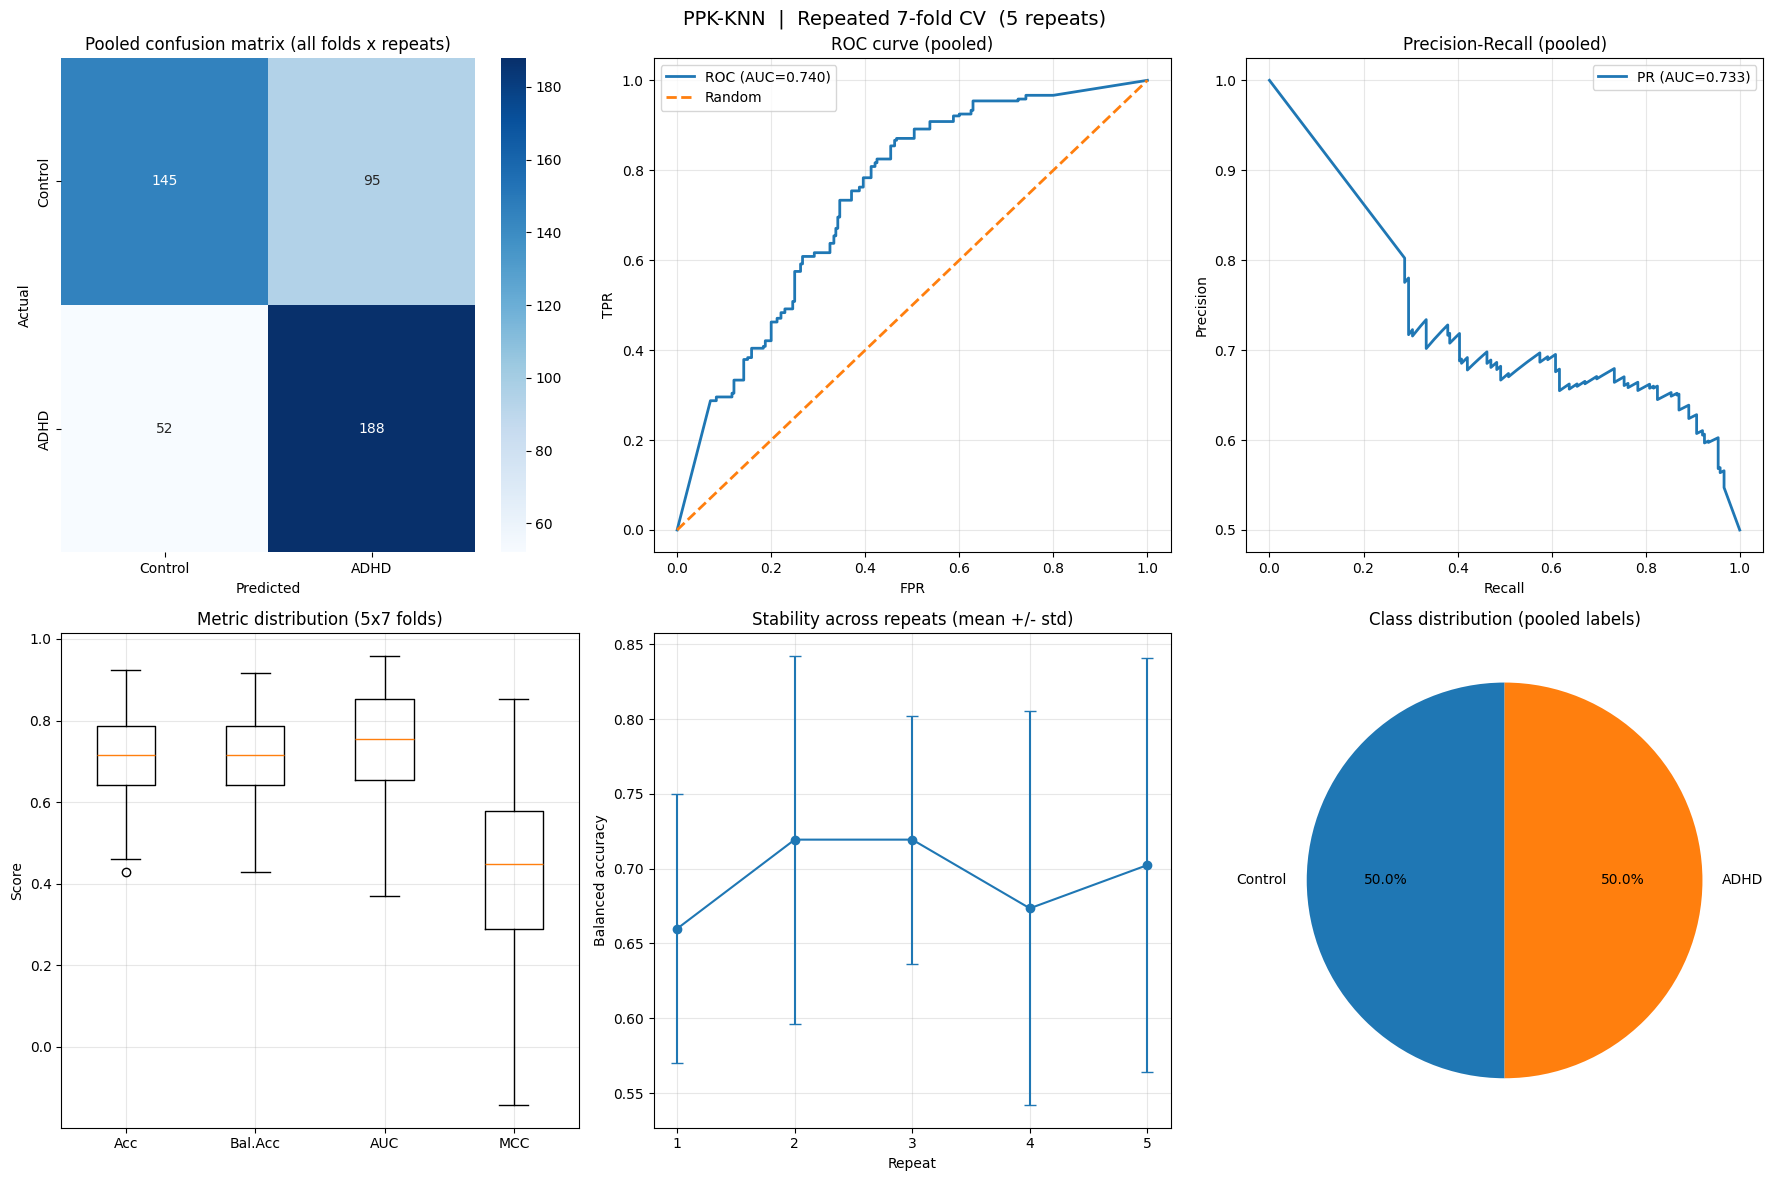


Optuna trials saved to: /content/drive/MyDrive/multivariate_frontal_hmms_n5_f7_ppk_knn_repeated_kfold_results.csv
Per-subject results saved.

ANALYSIS COMPLETE
Best rho        : 0.419953
Best T          : 6
Best k_neighbors: 3
Final test balanced accuracy: 0.8814


In [ ]:
"""
PPK-KNN Classification - Repeated K-Fold CV with subject traceability
"""

import numpy as np
import pandas as pd
import optuna
from numpy import pi as PI, exp, power
from numpy.linalg import det, inv
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, roc_auc_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# PPK KERNEL FUNCTIONS
def ppk_gaussian_similarity(mu1, Sigma1, mu2, Sigma2, rho=0.5, regularization=1e-6):
    D = mu1.shape[0]
    Sigma1_reg = Sigma1 + regularization * np.eye(D)
    Sigma2_reg = Sigma2 + regularization * np.eye(D)

    try:
        S1 = inv(Sigma1_reg)
        S2 = inv(Sigma2_reg)
        Sigma_combined = inv(rho * S1 + rho * S2)
    except np.linalg.LinAlgError:
        return 1e-10

    mu_combined = rho * (S1 @ mu1 + S2 @ mu2)

    try:
        det_combined = det(Sigma_combined)
        det1 = det(Sigma1_reg)
        det2 = det(Sigma2_reg)

        if det_combined <= 0 or det1 <= 0 or det2 <= 0:
            return 1e-10

        z = power(2 * PI, (1 - 2*rho) * D / 2) * \
            power(det_combined, 1/2) * \
            power(det1, -rho/2) * \
            power(det2, -rho/2)
    except Exception:
        return 1e-10

    q = -rho/2 * (mu1.T @ S1 @ mu1) - \
        rho/2 * (mu2.T @ S2 @ mu2) + \
        1/2 * (mu_combined.T @ Sigma_combined @ mu_combined)

    if not np.isfinite(q) or not np.isfinite(z):
        return 1e-10

    return z * exp(q)


def ppk_kernel(hmm1, hmm2, T=1, rho=0.5):
    pi1, A1, mu1, Sigma1 = hmm1['pi'], hmm1['A'], hmm1['mu'], hmm1['Sigma']
    pi2, A2, mu2, Sigma2 = hmm2['pi'], hmm2['A'], hmm2['mu'], hmm2['Sigma']

    M, N = pi1.shape[0], pi2.shape[0]

    Psi = np.zeros((M, N))
    for i in range(M):
        for j in range(N):
            Psi[i, j] = ppk_gaussian_similarity(mu1[i], Sigma1[i], mu2[j], Sigma2[j], rho)

    alpha = np.power(np.outer(pi1, pi2), rho) * Psi

    for t in range(T):
        alpha = A1.T @ alpha @ A2
        alpha = np.power(alpha, rho) * Psi

    return np.sum(alpha)


# DATA LOADING
def load_hmm_from_csv_row(row, n_states, n_components, n_features):
    """
    Load HMM parameters from a CSV row.
    Reads pi from 'pi_i' columns (initial distribution, not stationary).
    Covariance matrices are stored in upper triangular format.
    """
    pi = np.array([row[f'pi_{i}'] for i in range(n_states)])

    A = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            A[i, j] = row[f'A_{i}{j}']

    mu = np.zeros((n_states, n_features))
    Sigma = np.zeros((n_states, n_features, n_features))

    for state in range(n_states):
        weights = [row[f'gmm_weight_{state}_{k}'] for k in range(n_components)]
        best_comp = np.argmax(weights)

        for feat in range(n_features):
            mu[state, feat] = row[f'gmm_mean_{state}_{best_comp}_f{feat}']

        for i in range(n_features):
            for j in range(n_features):
                if i <= j:
                    col_name = f'gmm_cov_{state}_{best_comp}_f{i}f{j}'
                    Sigma[state, i, j] = row[col_name]
                else:
                    Sigma[state, i, j] = Sigma[state, j, i]

    return {'pi': pi, 'A': A, 'mu': mu, 'Sigma': Sigma}


def load_data(csv_path, n_states, n_components, n_features=None):
    df = pd.read_csv(csv_path)

    if n_features is None:
        n_features = int(df['n_features'].iloc[0])

    hmms = []
    labels = []
    subject_ids = []

    print(f"Loading HMMs from {csv_path}...")

    if 'filename_base' not in df.columns:
        print("[WARNING] Column 'filename_base' not found. Using row index as subject ID.")

    for idx, row in df.iterrows():
        hmm = load_hmm_from_csv_row(row, n_states, n_components, n_features)
        hmms.append(hmm)
        labels.append(1 if row['dataset_type'] == 'ADHD' else 0)
        subject_ids.append(row.get('filename_base', f'subject_{idx}'))

    labels = np.array(labels)
    subject_ids = np.array(subject_ids)

    print(f"  Loaded {len(hmms)} subjects")
    print(f"  ADHD: {np.sum(labels==1)}, Control: {np.sum(labels==0)}")
    print(f"  States: {n_states}, Components: {n_components}, Features: {n_features}")

    return hmms, labels, subject_ids


# SIMILARITY MATRIX COMPUTATION
def compute_similarity_matrix(hmms, T, rho):
    """Compute normalized PPK similarity matrix (values in [0, 1])."""
    n = len(hmms)
    K = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            K[i, j] = ppk_kernel(hmms[i], hmms[j], T=T, rho=rho)
            K[j, i] = K[i, j]

    K_norm = np.zeros_like(K)
    for i in range(n):
        for j in range(n):
            denom = np.sqrt(K[i, i] * K[j, j])
            K_norm[i, j] = K[i, j] / denom if denom > 1e-10 else 0.0

    return np.clip(K_norm, 0, 1)


# SUBJECT ROSTER
def print_subject_roster(subject_ids, y_train, y_test, idx_train, idx_test):
    label_map = {0: 'Control', 1: 'ADHD'}

    print("\n" + "="*60)
    print("SUBJECT ROSTER — TRAIN / TEST SPLIT")
    print("="*60)

    print(f"\n--- TRAIN SET ({len(idx_train)} subjects) ---")
    train_rows = sorted(zip(subject_ids[idx_train], y_train), key=lambda x: x[1])
    for sid, lbl in train_rows:
        print(f"  {sid:<40}  {label_map[lbl]}")

    print(f"\n--- TEST SET ({len(idx_test)} subjects) ---")
    test_rows = sorted(zip(subject_ids[idx_test], y_test), key=lambda x: x[1])
    for sid, lbl in test_rows:
        print(f"  {sid:<40}  {label_map[lbl]}")

    print(f"\nTrain -> Control: {np.sum(y_train==0)}  ADHD: {np.sum(y_train==1)}")
    print(f"Test  -> Control: {np.sum(y_test==0)}  ADHD: {np.sum(y_test==1)}")


# PER-SUBJECT TEST RESULTS
def print_subject_test_results(subject_ids_test, y_test, y_pred, y_proba,
                                class_names=('Control', 'ADHD')):
    label_map = {0: class_names[0], 1: class_names[1]}

    def quadrant(true, pred):
        if   true == 0 and pred == 0: return 'TN'
        elif true == 1 and pred == 1: return 'TP'
        elif true == 0 and pred == 1: return 'FP'
        else:                          return 'FN'

    rows = []
    for i in range(len(y_test)):
        true_lbl = int(y_test[i])
        pred_lbl = int(y_pred[i])
        rows.append({
            'subject_id' : subject_ids_test[i],
            'true_class' : label_map[true_lbl],
            'pred_class' : label_map[pred_lbl],
            'P(ADHD)'    : round(float(y_proba[i]), 4),
            'correct'    : (true_lbl == pred_lbl),
            'CM_quadrant': quadrant(true_lbl, pred_lbl)
        })

    df = pd.DataFrame(rows).sort_values(['CM_quadrant', 'subject_id'])

    print("\n" + "="*60)
    print("PER-SUBJECT TEST SET RESULTS")
    print("="*60)

    quad_label = {
        'TP': 'TRUE POSITIVES  — ADHD correctly identified',
        'TN': 'TRUE NEGATIVES  — Control correctly identified',
        'FP': 'FALSE POSITIVES — Control misclassified as ADHD',
        'FN': 'FALSE NEGATIVES — ADHD misclassified as Control'
    }

    for q in ['TP', 'TN', 'FP', 'FN']:
        subset = df[df['CM_quadrant'] == q]
        print(f"\n  [{q}] {quad_label[q]}  (n={len(subset)})")
        if len(subset) == 0:
            print("       (none)")
            continue
        header = f"  {'Subject ID':<40}  {'True':<10}  {'Pred':<10}  {'P(ADHD)':>8}"
        print(header)
        print("  " + "-" * (len(header) - 2))
        for _, r in subset.iterrows():
            marker = "" if r['correct'] else "  <-- misclassified"
            print(f"  {r['subject_id']:<40}  {r['true_class']:<10}  {r['pred_class']:<10}  "
                  f"{r['P(ADHD)']:>8.4f}{marker}")

    correct_n = df['correct'].sum()
    print(f"\n  Summary: {correct_n}/{len(df)} correctly classified, "
          f"{len(df)-correct_n}/{len(df)} misclassified")
    return df


# REPEATED K-FOLD CROSS-VALIDATION
def repeated_kfold_cross_validation_ppk_knn(hmms_train, y_train, rho, T, k_neighbors,
                                             n_splits=5, n_repeats=5,
                                             base_random_state=0):
    """
    Repeated stratified K-fold CV for PPK-KNN.

    The PPK similarity matrix is computed ONCE (expensive O(n^2) step)
    and reused across all folds and repeats.
    Each repeat r uses fold seed = base_random_state + r.
    """
    print(f"\n  Computing PPK similarity matrix (T={T}, rho={rho:.6g})...")
    K_norm = compute_similarity_matrix(hmms_train, T, rho)
    D_full = np.maximum(1 - K_norm, 0)
    np.fill_diagonal(D_full, 0)
    print(f"  Done. D stats: min={D_full.min():.6f}, max={D_full.max():.6f}, "
          f"mean={D_full.mean():.6f}")

    all_results = {
        'accuracy'         : [],
        'balanced_accuracy': [],
        'auc_roc'          : [],
        'mcc'              : [],
        'predictions'      : [],
        'probabilities'    : [],
        'true_labels'      : [],
        'confusion_matrices': [],
        'repeat_index'     : [],
        'fold_index'       : [],
        'fold_seed'        : [],
    }

    total_folds = n_splits * n_repeats
    global_fold = 0

    print(f"\n  Repeated {n_splits}-fold CV  |  repeats={n_repeats}  |  "
          f"total folds={total_folds}")
    print(f"  Seed scheme: repeat r uses random_state = base({base_random_state}) + r")

    for r in range(n_repeats):
        fold_seed = base_random_state + r
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=fold_seed)

        print(f"\n  -- Repeat {r+1}/{n_repeats}  (fold seed={fold_seed}) --")

        for fold, (train_idx, val_idx) in enumerate(skf.split(hmms_train, y_train)):
            global_fold += 1
            print(f"     Fold {fold+1}/{n_splits}  (global fold {global_fold}/{total_folds})")

            D_train = D_full[np.ix_(train_idx, train_idx)]
            D_val   = D_full[np.ix_(val_idx,   train_idx)]

            knn = KNeighborsClassifier(
                n_neighbors=k_neighbors, metric='precomputed', weights='distance'
            )
            knn.fit(D_train, y_train[train_idx])

            y_pred  = knn.predict(D_val)
            y_proba = knn.predict_proba(D_val)[:, 1]

            acc  = accuracy_score(y_train[val_idx], y_pred)
            bacc = balanced_accuracy_score(y_train[val_idx], y_pred)
            auc_ = roc_auc_score(y_train[val_idx], y_proba)
            mcc  = matthews_corrcoef(y_train[val_idx], y_pred)
            cm   = confusion_matrix(y_train[val_idx], y_pred)

            all_results['accuracy'].append(acc)
            all_results['balanced_accuracy'].append(bacc)
            all_results['auc_roc'].append(auc_)
            all_results['mcc'].append(mcc)
            all_results['confusion_matrices'].append(cm)
            all_results['predictions'].extend(y_pred.tolist())
            all_results['probabilities'].extend(y_proba.tolist())
            all_results['true_labels'].extend(y_train[val_idx].tolist())
            all_results['repeat_index'].append(r)
            all_results['fold_index'].append(fold)
            all_results['fold_seed'].append(fold_seed)

            print(f"       Acc={acc:.4f}, BalAcc={bacc:.4f}, AUC={auc_:.4f}, MCC={mcc:.4f}")

    for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'mcc',
              'repeat_index', 'fold_index', 'fold_seed']:
        all_results[k] = np.array(all_results[k])
    all_results['predictions']  = np.array(all_results['predictions'])
    all_results['probabilities'] = np.array(all_results['probabilities'])
    all_results['true_labels']   = np.array(all_results['true_labels'])

    return all_results


# OPTUNA OBJECTIVE — repeated K-fold averaged
def objective(trial, hmms_train, y_train, rho_range, T_range, k_neighbors_range,
              n_splits, n_repeats, base_random_state):
    rho        = trial.suggest_float('rho', rho_range[0], rho_range[1])
    T          = trial.suggest_int('T', T_range[0], T_range[1])
    k_neighbors = trial.suggest_int('k_neighbors', k_neighbors_range[0],
                                    k_neighbors_range[1], step=2)

    K_norm = compute_similarity_matrix(hmms_train, T, rho)
    D = np.maximum(1 - np.clip(K_norm, 0, 1), 0)
    np.fill_diagonal(D, 0)

    scores = []
    for r in range(n_repeats):
        fold_seed = base_random_state + r
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=fold_seed)
        for train_idx, val_idx in skf.split(hmms_train, y_train):
            D_train = D[np.ix_(train_idx, train_idx)]
            D_val   = D[np.ix_(val_idx,   train_idx)]
            knn = KNeighborsClassifier(
                n_neighbors=k_neighbors, metric='precomputed', weights='distance'
            )
            knn.fit(D_train, y_train[train_idx])
            y_pred = knn.predict(D_val)
            scores.append(balanced_accuracy_score(y_train[val_idx], y_pred))

    return float(np.mean(scores))


def optimize_hyperparameters(hmms_train, y_train, rho_range, T_range, k_neighbors_range,
                             n_trials, n_splits, n_repeats, base_random_state, timeout):
    print("\n" + "="*60)
    print("STARTING HYPERPARAMETER OPTIMIZATION (PPK-KNN, repeated K-fold)")
    print("="*60)
    print(f"  rho range        : {rho_range}")
    print(f"  T range          : {T_range}")
    print(f"  k_neighbors range: {k_neighbors_range}")
    print(f"  n_trials         : {n_trials}")
    print(f"  n_splits         : {n_splits}  |  n_repeats: {n_repeats}")
    print(f"  timeout          : {timeout}s ({timeout/3600:.1f}h)")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        lambda trial: objective(trial, hmms_train, y_train, rho_range, T_range,
                                k_neighbors_range, n_splits, n_repeats, base_random_state),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"  Best balanced accuracy : {study.best_value:.4f}")
    print(f"  Best rho               : {study.best_params['rho']:.6g}")
    print(f"  Best T                 : {study.best_params['T']}")
    print(f"  Best k_neighbors       : {study.best_params['k_neighbors']}")

    return study


# TEST SET EVALUATION WITH SUBJECT TRACEABILITY
def evaluate_on_test_set(hmms_train, y_train, hmms_test, y_test,
                          subject_ids_test, best_params):
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)

    rho        = best_params['rho']
    T          = best_params['T']
    k_neighbors = best_params['k_neighbors']
    n_train    = len(hmms_train)
    n_test     = len(hmms_test)

    print(f"  Parameters: T={T}, rho={rho:.6g}, k={k_neighbors}")
    print(f"  Train: {n_train}  |  Test: {n_test}")

    # Train-train kernel
    print("  Computing train-train kernel...")
    K_tt = np.zeros((n_train, n_train))
    for i in range(n_train):
        for j in range(i, n_train):
            K_tt[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_tt[j, i] = K_tt[i, j]

    # Test self-kernels (for normalization)
    print("  Computing test self-kernels...")
    K_test_diag = np.array([ppk_kernel(hmms_test[i], hmms_test[i], T=T, rho=rho)
                             for i in range(n_test)])

    # Test-train kernel
    print("  Computing test-train kernel...")
    K_test_train = np.zeros((n_test, n_train))
    for i in range(n_test):
        for j in range(n_train):
            K_test_train[i, j] = ppk_kernel(hmms_test[i], hmms_train[j], T=T, rho=rho)

    # Normalize
    K_train_diag = np.diag(K_tt)
    K_tt_norm = np.zeros_like(K_tt)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_train_diag[i] * K_train_diag[j])
            K_tt_norm[i, j] = K_tt[i, j] / denom if denom > 1e-10 else 0.0

    K_test_norm = np.zeros_like(K_test_train)
    for i in range(n_test):
        for j in range(n_train):
            denom = np.sqrt(K_test_diag[i] * K_train_diag[j])
            K_test_norm[i, j] = K_test_train[i, j] / denom if denom > 1e-10 else 0.0

    K_tt_norm   = np.clip(K_tt_norm,   0, 1)
    K_test_norm = np.clip(K_test_norm, 0, 1)

    D_train = np.maximum(1 - K_tt_norm,   0); np.fill_diagonal(D_train, 0)
    D_test  = np.maximum(1 - K_test_norm, 0)

    print(f"  D_train: min={D_train.min():.6f}, max={D_train.max():.6f}, mean={D_train.mean():.6f}")
    print(f"  D_test : min={D_test.min():.6f},  max={D_test.max():.6f},  mean={D_test.mean():.6f}")

    knn = KNeighborsClassifier(n_neighbors=k_neighbors, metric='precomputed', weights='distance')
    knn.fit(D_train, y_train)

    y_pred  = knn.predict(D_test)
    y_proba = knn.predict_proba(D_test)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    test_bal_acc  = balanced_accuracy_score(y_test, y_pred)
    test_auc      = roc_auc_score(y_test, y_proba)
    test_mcc      = matthews_corrcoef(y_test, y_pred)
    test_cm       = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print("TEST RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy           : {test_accuracy:.4f}")
    print(f"  Balanced Accuracy  : {test_bal_acc:.4f}")
    print(f"  AUC-ROC            : {test_auc:.4f}")
    print(f"  Matthews Corr      : {test_mcc:.4f}")
    print(f"\nTest Confusion Matrix:")
    print(f"              Control  ADHD")
    print(f"Control       {test_cm[0,0]:<7} {test_cm[0,1]:<7}")
    print(f"ADHD          {test_cm[1,0]:<7} {test_cm[1,1]:<7}")

    subject_results_df = print_subject_test_results(
        subject_ids_test, y_test, y_pred, y_proba
    )

    return {
        'accuracy'         : test_accuracy,
        'balanced_accuracy': test_bal_acc,
        'auc_roc'          : test_auc,
        'mcc'              : test_mcc,
        'confusion_matrix' : test_cm,
        'predictions'      : y_pred,
        'probabilities'    : y_proba,
        'y_true'           : y_test,
        'subject_results_df': subject_results_df
    }


# EVALUATION PLOTS — adapted for repeated CV
def create_evaluation_plots(fold_results, n_repeats, n_splits,
                             class_names=('Control', 'ADHD')):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'PPK-KNN  |  Repeated {n_splits}-fold CV  ({n_repeats} repeats)', fontsize=14)

    overall_cm = confusion_matrix(fold_results['true_labels'], fold_results['predictions'])
    sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
    axes[0, 0].set_title('Pooled confusion matrix (all folds x repeats)')
    axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(fold_results['true_labels'], fold_results['probabilities'])
    auc_score = auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, lw=2, label=f'ROC (AUC={auc_score:.3f})')
    axes[0, 1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random')
    axes[0, 1].set_xlabel('FPR'); axes[0, 1].set_ylabel('TPR')
    axes[0, 1].set_title('ROC curve (pooled)'); axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    precision, recall, _ = precision_recall_curve(
        fold_results['true_labels'], fold_results['probabilities']
    )
    pr_auc = auc(recall, precision)
    axes[0, 2].plot(recall, precision, lw=2, label=f'PR (AUC={pr_auc:.3f})')
    axes[0, 2].set_xlabel('Recall'); axes[0, 2].set_ylabel('Precision')
    axes[0, 2].set_title('Precision-Recall (pooled)'); axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    metrics_data = [fold_results['accuracy'], fold_results['balanced_accuracy'],
                    fold_results['auc_roc'],   fold_results['mcc']]
    axes[1, 0].boxplot(metrics_data, labels=['Acc', 'Bal.Acc', 'AUC', 'MCC'])
    axes[1, 0].set_title(f'Metric distribution ({n_repeats}x{n_splits} folds)')
    axes[1, 0].set_ylabel('Score'); axes[1, 0].grid(True, alpha=0.3)

    repeat_means, repeat_stds = [], []
    for r in range(n_repeats):
        mask = fold_results['repeat_index'] == r
        vals = fold_results['balanced_accuracy'][mask]
        repeat_means.append(vals.mean())
        repeat_stds.append(vals.std())
    x = np.arange(1, n_repeats + 1)
    axes[1, 1].errorbar(x, repeat_means, yerr=repeat_stds, fmt='o-', capsize=4)
    axes[1, 1].set_xlabel('Repeat'); axes[1, 1].set_ylabel('Balanced accuracy')
    axes[1, 1].set_title('Stability across repeats (mean +/- std)')
    axes[1, 1].set_xticks(x); axes[1, 1].grid(True, alpha=0.3)

    class_counts = np.bincount(fold_results['true_labels'])
    axes[1, 2].pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1, 2].set_title('Class distribution (pooled labels)')

    plt.tight_layout()
    plt.show()


# FULL ANALYSIS PIPELINE
def run_complete_analysis(csv_path,
                          test_size=0.2,
                          split_random_state=42,     # fixed — never changes
                          base_cv_random_state=0,    # CV seeds: 0, 1, ..., n_repeats-1
                          rho_range=(0.1, 0.9),
                          T_range=(1, 7),
                          k_neighbors_range=(1, 9),
                          n_trials=100,
                          n_splits=5,
                          n_repeats=5,
                          timeout=3600,
                          n_states=3, n_components=3, n_features=None):

    print("\n" + "="*60)
    print("PPK-KNN CLASSIFICATION — REPEATED K-FOLD CV")
    print("="*60)
    print(f"  Train/test split seed : {split_random_state}  (fixed)")
    print(f"  CV base seed          : {base_cv_random_state}")
    print(f"  CV fold seeds         : {[base_cv_random_state + r for r in range(n_repeats)]}")
    print(f"  n_splits x n_repeats  : {n_splits} x {n_repeats} = {n_splits*n_repeats} total folds")

    hmms, labels, subject_ids = load_data(csv_path, n_states, n_components, n_features)

    # Fixed train/test split
    indices = np.arange(len(hmms))
    idx_train, idx_test, y_train, y_test = train_test_split(
        indices, labels, test_size=test_size,
        random_state=split_random_state, stratify=labels
    )

    hmms_train      = [hmms[i] for i in idx_train]
    hmms_test       = [hmms[i] for i in idx_test]
    subject_ids_test = subject_ids[idx_test]

    print(f"\n  Train: {len(hmms_train)} subjects  "
          f"(ADHD: {np.sum(y_train==1)}, Control: {np.sum(y_train==0)})")
    print(f"  Test : {len(hmms_test)} subjects  "
          f"(ADHD: {np.sum(y_test==1)}, Control: {np.sum(y_test==0)})")

    # Print subject roster immediately after the split
    print_subject_roster(subject_ids, y_train, y_test, idx_train, idx_test)

    # Optimization: objective averaged over repeated K-fold
    study = optimize_hyperparameters(
        hmms_train, y_train, rho_range, T_range, k_neighbors_range,
        n_trials, n_splits, n_repeats, base_cv_random_state, timeout
    )
    best_params = study.best_params

    # Final repeated CV with best params
    print("\nFinal repeated K-fold CV with best parameters...")
    fold_results = repeated_kfold_cross_validation_ppk_knn(
        hmms_train, y_train,
        rho=best_params['rho'],
        T=best_params['T'],
        k_neighbors=best_params['k_neighbors'],
        n_splits=n_splits,
        n_repeats=n_repeats,
        base_random_state=base_cv_random_state
    )

    print("\n" + "="*60)
    print("REPEATED K-FOLD CV RESULTS")
    print("="*60)
    print(f"  rho             : {best_params['rho']:.6g}")
    print(f"  T               : {best_params['T']}")
    print(f"  k_neighbors     : {best_params['k_neighbors']}")
    print(f"  folds x repeats : {n_splits} x {n_repeats} = {n_splits*n_repeats}")
    for name, key in [('Accuracy',         'accuracy'),
                      ('Balanced Accuracy', 'balanced_accuracy'),
                      ('AUC-ROC',           'auc_roc'),
                      ('MCC',               'mcc')]:
        vals = fold_results[key]
        print(f"  {name:<22}: {vals.mean():.4f} +/- {vals.std():.4f}  "
              f"[min={vals.min():.4f}, max={vals.max():.4f}]")

    print(f"\n  Per-repeat balanced accuracy:")
    for r in range(n_repeats):
        mask = fold_results['repeat_index'] == r
        vals = fold_results['balanced_accuracy'][mask]
        seed = int(fold_results['fold_seed'][mask][0])
        print(f"    Repeat {r+1} (seed={seed}): {vals.mean():.4f} +/- {vals.std():.4f}")

    # Test set evaluation
    test_results = evaluate_on_test_set(
        hmms_train, y_train, hmms_test, y_test, subject_ids_test, best_params
    )

    create_evaluation_plots(fold_results, n_repeats=n_repeats, n_splits=n_splits)

    output_file = csv_path.replace('.csv', '_ppk_knn_repeated_kfold_results.csv')
    df_trials = study.trials_dataframe()
    df_trials.to_csv(output_file, index=False)
    print(f"\nOptuna trials saved to: {output_file}")

    test_results['subject_results_df'].to_csv(
        csv_path.replace('.csv', '_ppk_knn_subject_test_results.csv'), index=False
    )
    print("Per-subject results saved.")

    return {
        'study'       : study,
        'best_params' : best_params,
        'fold_results': fold_results,
        'test_results': test_results,
        'trials_df'   : df_trials
    }


if __name__ == "__main__":
    results = run_complete_analysis(
        # csv_path='.../synthetic_hmms_results.csv',
        csv_path='.../NxGx/hmm_results.csv',
        test_size=0.2,
        split_random_state=42,      # train/test split — never changes
        base_cv_random_state=0,     # CV seeds: 0, 1, 2, ... (n_repeats - 1)
        rho_range=(0.1, 1.0),
        T_range=(1, 15),
        k_neighbors_range=(1, 11),
        n_trials=3500,
        n_splits=7,
        n_repeats=5,                # 5 x 10 = 50 total folds
        timeout=(60 * 60 * 1),
        n_states=3,
        n_components=3,
        n_features=None
    )

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Best rho        : {results['best_params']['rho']:.6g}")
    print(f"Best T          : {results['best_params']['T']}")
    print(f"Best k_neighbors: {results['best_params']['k_neighbors']}")
    print(f"Final test balanced accuracy: "
          f"{results['test_results']['balanced_accuracy']:.4f}")

# Probability Product Kernel - SVM Classification


PPK-SVM CLASSIFICATION — REPEATED K-FOLD CV
  Train/test split seed : 42  (fixed)
  CV base seed          : 0
  CV fold seeds         : [0, 1, 2, 3, 4]
  n_splits x n_repeats  : 7 x 5 = 35 total folds
Loading HMMs from /content/drive/MyDrive/multivariate_frontal_hmms_n5_f7.csv...


[I 2026-03-31 16:43:37,135] A new study created in memory with name: no-name-edc4a46c-4500-4a15-b7d3-4706ec046412


  Loaded 121 subjects
  ADHD: 61, Control: 60
  States: 3, Components: 3, Features: 7

  Train: 96 subjects  (ADHD: 48, Control: 48)
  Test : 25 subjects  (ADHD: 13, Control: 12)

SUBJECT ROSTER — TRAIN / TEST SPLIT

--- TRAIN SET (96 subjects) ---
  v129_preprocessed                         Control
  v113_preprocessed                         Control
  v57p_preprocessed                         Control
  v42p_preprocessed                         Control
  v151_preprocessed                         Control
  v44p_preprocessed                         Control
  v115_preprocessed                         Control
  v45p_preprocessed                         Control
  v59p_preprocessed                         Control
  v58p_preprocessed                         Control
  v41p_preprocessed                         Control
  v299_preprocessed                         Control
  v310_preprocessed                         Control
  v49p_preprocessed                         Control
  v308_preprocessed    

  0%|          | 0/3500 [00:00<?, ?it/s]

[I 2026-03-31 16:43:51,454] Trial 0 finished with value: 0.6802721088435374 and parameters: {'rho': 0.4370861069626263, 'T': 15, 'gamma': 0.05100627805979915, 'C': 41.28205343826221}. Best is trial 0 with value: 0.6802721088435374.
[I 2026-03-31 16:44:05,800] Trial 1 finished with value: 0.7261904761904763 and parameters: {'rho': 0.24041677639819287, 'T': 3, 'gamma': 0.0001640021491120233, 'C': 217.66241123453668}. Best is trial 1 with value: 0.7261904761904763.
[I 2026-03-31 16:44:13,460] Trial 2 finished with value: 0.6010204081632654 and parameters: {'rho': 0.6410035105688879, 'T': 11, 'gamma': 0.00011916299962955152, 'C': 414.72250004816334}. Best is trial 1 with value: 0.7261904761904763.
[I 2026-03-31 16:44:18,886] Trial 3 finished with value: 0.6071428571428572 and parameters: {'rho': 0.8491983767203796, 'T': 4, 'gamma': 0.0004705059281907648, 'C': 3.126102910311059}. Best is trial 1 with value: 0.7261904761904763.
[I 2026-03-31 16:44:23,216] Trial 4 finished with value: 0.69319

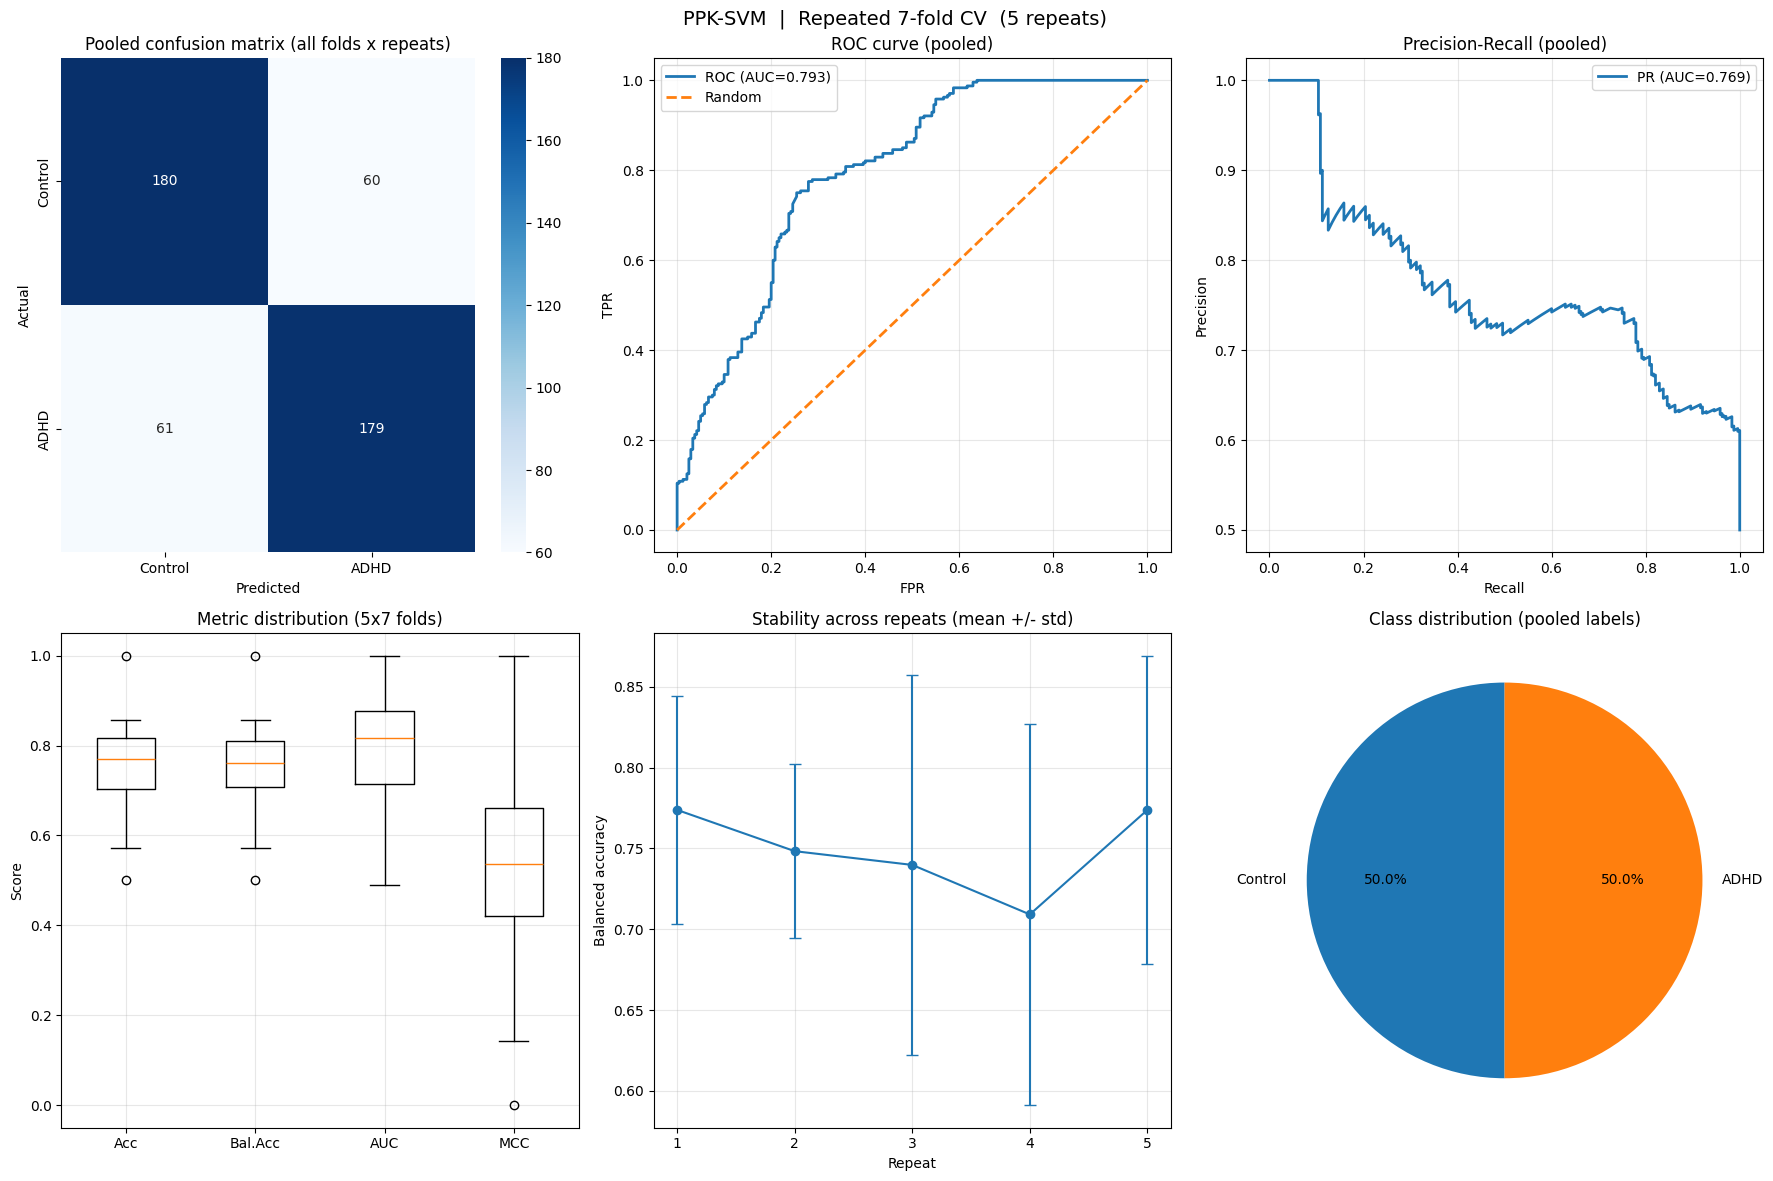


Optuna trials saved to: /content/drive/MyDrive/multivariate_frontal_hmms_n5_f7_ppk_svm_repeated_kfold_results.csv
Per-subject results saved.

ANALYSIS COMPLETE
Best rho   : 0.23619
Best T     : 11
Best gamma : 0.000402158
Best C     : 2.77846
Final test balanced accuracy: 0.7179


In [ ]:
"""
PPK-SVM Classification - Repeated K-Fold CV with subject traceability
"""

import numpy as np
import pandas as pd
import optuna
from numpy import pi as PI, exp, power
from numpy.linalg import det, inv
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve, roc_auc_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# PPK KERNEL FUNCTIONS
def ppk_gaussian_similarity(mu1, Sigma1, mu2, Sigma2, rho=0.5, regularization=1e-6):
    D = mu1.shape[0]
    Sigma1_reg = Sigma1 + regularization * np.eye(D)
    Sigma2_reg = Sigma2 + regularization * np.eye(D)

    try:
        S1 = inv(Sigma1_reg)
        S2 = inv(Sigma2_reg)
        Sigma_combined = inv(rho * S1 + rho * S2)
    except np.linalg.LinAlgError:
        return 1e-10

    mu_combined = rho * (S1 @ mu1 + S2 @ mu2)

    try:
        det_combined = det(Sigma_combined)
        det1 = det(Sigma1_reg)
        det2 = det(Sigma2_reg)

        if det_combined <= 0 or det1 <= 0 or det2 <= 0:
            return 1e-10

        z = power(2 * PI, (1 - 2*rho) * D / 2) * \
            power(det_combined, 1/2) * \
            power(det1, -rho/2) * \
            power(det2, -rho/2)
    except Exception:
        return 1e-10

    q = -rho/2 * (mu1.T @ S1 @ mu1) - \
        rho/2 * (mu2.T @ S2 @ mu2) + \
        1/2 * (mu_combined.T @ Sigma_combined @ mu_combined)

    if not np.isfinite(q) or not np.isfinite(z):
        return 1e-10

    return z * exp(q)


def ppk_kernel(hmm1, hmm2, T=1, rho=0.5):
    pi1, A1, mu1, Sigma1 = hmm1['pi'], hmm1['A'], hmm1['mu'], hmm1['Sigma']
    pi2, A2, mu2, Sigma2 = hmm2['pi'], hmm2['A'], hmm2['mu'], hmm2['Sigma']

    M, N = pi1.shape[0], pi2.shape[0]

    Psi = np.zeros((M, N))
    for i in range(M):
        for j in range(N):
            Psi[i, j] = ppk_gaussian_similarity(mu1[i], Sigma1[i], mu2[j], Sigma2[j], rho)

    alpha = np.power(np.outer(pi1, pi2), rho) * Psi

    for t in range(T):
        alpha = A1.T @ alpha @ A2
        alpha = np.power(alpha, rho) * Psi

    return np.sum(alpha)


# DATA LOADING
def load_hmm_from_csv_row(row, n_states, n_components, n_features):
    """
    Load HMM parameters from a CSV row.
    Reads pi from 'pi_i' columns (initial distribution, not stationary).
    Covariance matrices are stored in upper triangular format.
    """
    pi = np.array([row[f'pi_{i}'] for i in range(n_states)])

    A = np.zeros((n_states, n_states))
    for i in range(n_states):
        for j in range(n_states):
            A[i, j] = row[f'A_{i}{j}']

    mu = np.zeros((n_states, n_features))
    Sigma = np.zeros((n_states, n_features, n_features))

    for state in range(n_states):
        weights = [row[f'gmm_weight_{state}_{k}'] for k in range(n_components)]
        best_comp = np.argmax(weights)

        for feat in range(n_features):
            mu[state, feat] = row[f'gmm_mean_{state}_{best_comp}_f{feat}']

        for i in range(n_features):
            for j in range(n_features):
                if i <= j:
                    col_name = f'gmm_cov_{state}_{best_comp}_f{i}f{j}'
                    Sigma[state, i, j] = row[col_name]
                else:
                    Sigma[state, i, j] = Sigma[state, j, i]

    return {'pi': pi, 'A': A, 'mu': mu, 'Sigma': Sigma}


def load_data(csv_path, n_states, n_components, n_features=None):
    df = pd.read_csv(csv_path)

    if n_features is None:
        n_features = int(df['n_features'].iloc[0])

    hmms = []
    labels = []
    subject_ids = []

    print(f"Loading HMMs from {csv_path}...")

    if 'filename_base' not in df.columns:
        print("[WARNING] Column 'filename_base' not found. Using row index as subject ID.")

    for idx, row in df.iterrows():
        hmm = load_hmm_from_csv_row(row, n_states, n_components, n_features)
        hmms.append(hmm)
        labels.append(1 if row['dataset_type'] == 'ADHD' else 0)
        subject_ids.append(row.get('filename_base', f'subject_{idx}'))

    labels = np.array(labels)
    subject_ids = np.array(subject_ids)

    print(f"  Loaded {len(hmms)} subjects")
    print(f"  ADHD: {np.sum(labels==1)}, Control: {np.sum(labels==0)}")
    print(f"  States: {n_states}, Components: {n_components}, Features: {n_features}")

    return hmms, labels, subject_ids


# SIMILARITY MATRIX COMPUTATION
def compute_similarity_matrix(hmms, T, rho):
    """Compute normalized PPK similarity matrix (values in [0, 1])."""
    n = len(hmms)
    K = np.zeros((n, n))

    for i in range(n):
        for j in range(i, n):
            K[i, j] = ppk_kernel(hmms[i], hmms[j], T=T, rho=rho)
            K[j, i] = K[i, j]

    K_norm = np.zeros_like(K)
    for i in range(n):
        for j in range(n):
            denom = np.sqrt(K[i, i] * K[j, j])
            K_norm[i, j] = K[i, j] / denom if denom > 1e-10 else 0.0

    return np.clip(K_norm, 0, 1)


# SUBJECT ROSTER
def print_subject_roster(subject_ids, y_train, y_test, idx_train, idx_test):
    label_map = {0: 'Control', 1: 'ADHD'}

    print("\n" + "="*60)
    print("SUBJECT ROSTER — TRAIN / TEST SPLIT")
    print("="*60)

    print(f"\n--- TRAIN SET ({len(idx_train)} subjects) ---")
    train_rows = sorted(zip(subject_ids[idx_train], y_train), key=lambda x: x[1])
    for sid, lbl in train_rows:
        print(f"  {sid:<40}  {label_map[lbl]}")

    print(f"\n--- TEST SET ({len(idx_test)} subjects) ---")
    test_rows = sorted(zip(subject_ids[idx_test], y_test), key=lambda x: x[1])
    for sid, lbl in test_rows:
        print(f"  {sid:<40}  {label_map[lbl]}")

    print(f"\nTrain -> Control: {np.sum(y_train==0)}  ADHD: {np.sum(y_train==1)}")
    print(f"Test  -> Control: {np.sum(y_test==0)}  ADHD: {np.sum(y_test==1)}")


# PER-SUBJECT TEST RESULTS
def print_subject_test_results(subject_ids_test, y_test, y_pred, y_proba,
                                class_names=('Control', 'ADHD')):
    label_map = {0: class_names[0], 1: class_names[1]}

    def quadrant(true, pred):
        if   true == 0 and pred == 0: return 'TN'
        elif true == 1 and pred == 1: return 'TP'
        elif true == 0 and pred == 1: return 'FP'
        else:                          return 'FN'

    rows = []
    for i in range(len(y_test)):
        true_lbl = int(y_test[i])
        pred_lbl = int(y_pred[i])
        rows.append({
            'subject_id' : subject_ids_test[i],
            'true_class' : label_map[true_lbl],
            'pred_class' : label_map[pred_lbl],
            'P(ADHD)'    : round(float(y_proba[i]), 4),
            'correct'    : (true_lbl == pred_lbl),
            'CM_quadrant': quadrant(true_lbl, pred_lbl)
        })

    df = pd.DataFrame(rows).sort_values(['CM_quadrant', 'subject_id'])

    print("\n" + "="*60)
    print("PER-SUBJECT TEST SET RESULTS")
    print("="*60)

    quad_label = {
        'TP': 'TRUE POSITIVES  — ADHD correctly identified',
        'TN': 'TRUE NEGATIVES  — Control correctly identified',
        'FP': 'FALSE POSITIVES — Control misclassified as ADHD',
        'FN': 'FALSE NEGATIVES — ADHD misclassified as Control'
    }

    for q in ['TP', 'TN', 'FP', 'FN']:
        subset = df[df['CM_quadrant'] == q]
        print(f"\n  [{q}] {quad_label[q]}  (n={len(subset)})")
        if len(subset) == 0:
            print("       (none)")
            continue
        header = f"  {'Subject ID':<40}  {'True':<10}  {'Pred':<10}  {'P(ADHD)':>8}"
        print(header)
        print("  " + "-" * (len(header) - 2))
        for _, r in subset.iterrows():
            marker = "" if r['correct'] else "  <-- misclassified"
            print(f"  {r['subject_id']:<40}  {r['true_class']:<10}  {r['pred_class']:<10}  "
                  f"{r['P(ADHD)']:>8.4f}{marker}")

    correct_n = df['correct'].sum()
    print(f"\n  Summary: {correct_n}/{len(df)} correctly classified, "
          f"{len(df)-correct_n}/{len(df)} misclassified")
    return df


# REPEATED K-FOLD CROSS-VALIDATION WITH SVM
def repeated_kfold_cross_validation_ppk_svm(hmms_train, y_train, rho, T, gamma, C,
                                              n_splits=5, n_repeats=5,
                                              base_random_state=0):
    """
    Repeated stratified K-fold CV for PPK-SVM.

    The PPK similarity matrix is computed ONCE and reused across all
    folds and repeats. Each repeat r uses fold seed = base_random_state + r.
    The SVM random_state also tracks the fold seed for full reproducibility.
    """
    print(f"\n  Computing PPK similarity matrix (T={T}, rho={rho:.6g})...")
    K_norm = compute_similarity_matrix(hmms_train, T, rho)
    K_norm = np.clip(K_norm, 0, 1)
    print(f"  Done. K stats: min={K_norm.min():.6f}, max={K_norm.max():.6f}, "
          f"mean={K_norm.mean():.6f}")

    all_results = {
        'accuracy'         : [],
        'balanced_accuracy': [],
        'auc_roc'          : [],
        'mcc'              : [],
        'predictions'      : [],
        'probabilities'    : [],
        'true_labels'      : [],
        'confusion_matrices': [],
        'repeat_index'     : [],
        'fold_index'       : [],
        'fold_seed'        : [],
    }

    total_folds = n_splits * n_repeats
    global_fold = 0

    print(f"\n  Repeated {n_splits}-fold CV  |  repeats={n_repeats}  |  "
          f"total folds={total_folds}")
    print(f"  sigma={rho:.6g}, gamma={gamma:.6g}, C={C:.6g}")
    print(f"  Seed scheme: repeat r uses random_state = base({base_random_state}) + r")

    for r in range(n_repeats):
        fold_seed = base_random_state + r
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=fold_seed)

        print(f"\n  -- Repeat {r+1}/{n_repeats}  (fold seed={fold_seed}) --")

        for fold, (train_idx, val_idx) in enumerate(skf.split(hmms_train, y_train)):
            global_fold += 1
            print(f"     Fold {fold+1}/{n_splits}  (global fold {global_fold}/{total_folds})")

            K_train = K_norm[np.ix_(train_idx, train_idx)]
            K_val   = K_norm[np.ix_(val_idx,   train_idx)]

            svm = SVC(kernel='precomputed', C=C, gamma=gamma,
                      probability=True, random_state=fold_seed)
            svm.fit(K_train, y_train[train_idx])

            y_pred  = svm.predict(K_val)
            y_proba = svm.predict_proba(K_val)[:, 1]

            acc  = accuracy_score(y_train[val_idx], y_pred)
            bacc = balanced_accuracy_score(y_train[val_idx], y_pred)
            auc_ = roc_auc_score(y_train[val_idx], y_proba)
            mcc  = matthews_corrcoef(y_train[val_idx], y_pred)
            cm   = confusion_matrix(y_train[val_idx], y_pred)

            all_results['accuracy'].append(acc)
            all_results['balanced_accuracy'].append(bacc)
            all_results['auc_roc'].append(auc_)
            all_results['mcc'].append(mcc)
            all_results['confusion_matrices'].append(cm)
            all_results['predictions'].extend(y_pred.tolist())
            all_results['probabilities'].extend(y_proba.tolist())
            all_results['true_labels'].extend(y_train[val_idx].tolist())
            all_results['repeat_index'].append(r)
            all_results['fold_index'].append(fold)
            all_results['fold_seed'].append(fold_seed)

            print(f"       Acc={acc:.4f}, BalAcc={bacc:.4f}, AUC={auc_:.4f}, MCC={mcc:.4f}")

    for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'mcc',
              'repeat_index', 'fold_index', 'fold_seed']:
        all_results[k] = np.array(all_results[k])
    all_results['predictions']  = np.array(all_results['predictions'])
    all_results['probabilities'] = np.array(all_results['probabilities'])
    all_results['true_labels']   = np.array(all_results['true_labels'])

    return all_results


# OPTUNA OBJECTIVE — repeated K-fold averaged
def objective(trial, hmms_train, y_train, rho_range, T_range,
              gamma_range, C_range, n_splits, n_repeats, base_random_state):
    rho   = trial.suggest_float('rho',   rho_range[0],   rho_range[1])
    T     = trial.suggest_int('T',       T_range[0],     T_range[1])
    gamma = trial.suggest_float('gamma', gamma_range[0], gamma_range[1], log=True)
    C     = trial.suggest_float('C',     C_range[0],     C_range[1],     log=True)

    K_norm = compute_similarity_matrix(hmms_train, T, rho)
    K_norm = np.clip(K_norm, 0, 1)

    scores = []
    for r in range(n_repeats):
        fold_seed = base_random_state + r
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=fold_seed)
        for train_idx, val_idx in skf.split(hmms_train, y_train):
            K_train = K_norm[np.ix_(train_idx, train_idx)]
            K_val   = K_norm[np.ix_(val_idx,   train_idx)]
            svm = SVC(kernel='precomputed', C=C, gamma=gamma,
                      probability=True, random_state=fold_seed)
            svm.fit(K_train, y_train[train_idx])
            y_pred = svm.predict(K_val)
            scores.append(balanced_accuracy_score(y_train[val_idx], y_pred))

    return float(np.mean(scores))


def optimize_hyperparameters(hmms_train, y_train, rho_range, T_range,
                             gamma_range, C_range, n_trials, n_splits,
                             n_repeats, base_random_state, timeout):
    print("\n" + "="*60)
    print("STARTING HYPERPARAMETER OPTIMIZATION (PPK-SVM, repeated K-fold)")
    print("="*60)
    print(f"  rho range  : {rho_range}")
    print(f"  T range    : {T_range}")
    print(f"  gamma range: {gamma_range}")
    print(f"  C range    : {C_range}")
    print(f"  n_trials   : {n_trials}")
    print(f"  n_splits   : {n_splits}  |  n_repeats: {n_repeats}")
    print(f"  timeout    : {timeout}s ({timeout/3600:.1f}h)")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(
        lambda trial: objective(trial, hmms_train, y_train, rho_range, T_range,
                                gamma_range, C_range, n_splits, n_repeats,
                                base_random_state),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"  Best balanced accuracy : {study.best_value:.4f}")
    print(f"  Best rho               : {study.best_params['rho']:.6g}")
    print(f"  Best T                 : {study.best_params['T']}")
    print(f"  Best gamma             : {study.best_params['gamma']:.6g}")
    print(f"  Best C                 : {study.best_params['C']:.6g}")

    return study


# TEST SET EVALUATION WITH SUBJECT TRACEABILITY
def evaluate_on_test_set(hmms_train, y_train, hmms_test, y_test,
                          subject_ids_test, best_params):
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)

    rho   = best_params['rho']
    T     = best_params['T']
    gamma = best_params['gamma']
    C     = best_params['C']
    n_train = len(hmms_train)
    n_test  = len(hmms_test)

    print(f"  Parameters: T={T}, rho={rho:.6g}, gamma={gamma:.6g}, C={C:.6g}")
    print(f"  Train: {n_train}  |  Test: {n_test}")

    # Train-train kernel
    print("  Computing train-train kernel...")
    K_tt = np.zeros((n_train, n_train))
    for i in range(n_train):
        for j in range(i, n_train):
            K_tt[i, j] = ppk_kernel(hmms_train[i], hmms_train[j], T=T, rho=rho)
            K_tt[j, i] = K_tt[i, j]

    # Test self-kernels (for normalization)
    print("  Computing test self-kernels...")
    K_test_diag = np.array([ppk_kernel(hmms_test[i], hmms_test[i], T=T, rho=rho)
                             for i in range(n_test)])

    # Test-train kernel
    print("  Computing test-train kernel...")
    K_test_train = np.zeros((n_test, n_train))
    for i in range(n_test):
        for j in range(n_train):
            K_test_train[i, j] = ppk_kernel(hmms_test[i], hmms_train[j], T=T, rho=rho)

    # Normalize
    K_train_diag = np.diag(K_tt)
    K_tt_norm = np.zeros_like(K_tt)
    for i in range(n_train):
        for j in range(n_train):
            denom = np.sqrt(K_train_diag[i] * K_train_diag[j])
            K_tt_norm[i, j] = K_tt[i, j] / denom if denom > 1e-10 else 0.0

    K_test_norm = np.zeros_like(K_test_train)
    for i in range(n_test):
        for j in range(n_train):
            denom = np.sqrt(K_test_diag[i] * K_train_diag[j])
            K_test_norm[i, j] = K_test_train[i, j] / denom if denom > 1e-10 else 0.0

    K_tt_norm   = np.clip(K_tt_norm,   0, 1)
    K_test_norm = np.clip(K_test_norm, 0, 1)

    print(f"\n  Kernel diagnostics:")
    print(f"    K_train: min={K_tt_norm.min():.6f}, max={K_tt_norm.max():.6f}, "
          f"mean={K_tt_norm.mean():.6f}")
    print(f"    K_test : min={K_test_norm.min():.6f}, max={K_test_norm.max():.6f}, "
          f"mean={K_test_norm.mean():.6f}")

    svm = SVC(kernel='precomputed', C=C, gamma=gamma, probability=True, random_state=42)
    svm.fit(K_tt_norm, y_train)

    y_pred  = svm.predict(K_test_norm)
    y_proba = svm.predict_proba(K_test_norm)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    test_bal_acc  = balanced_accuracy_score(y_test, y_pred)
    test_auc      = roc_auc_score(y_test, y_proba)
    test_mcc      = matthews_corrcoef(y_test, y_pred)
    test_cm       = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print("TEST RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy           : {test_accuracy:.4f}")
    print(f"  Balanced Accuracy  : {test_bal_acc:.4f}")
    print(f"  AUC-ROC            : {test_auc:.4f}")
    print(f"  Matthews Corr      : {test_mcc:.4f}")
    print(f"\nTest Confusion Matrix:")
    print(f"              Control  ADHD")
    print(f"Control       {test_cm[0,0]:<7} {test_cm[0,1]:<7}")
    print(f"ADHD          {test_cm[1,0]:<7} {test_cm[1,1]:<7}")

    subject_results_df = print_subject_test_results(
        subject_ids_test, y_test, y_pred, y_proba
    )

    return {
        'accuracy'         : test_accuracy,
        'balanced_accuracy': test_bal_acc,
        'auc_roc'          : test_auc,
        'mcc'              : test_mcc,
        'confusion_matrix' : test_cm,
        'predictions'      : y_pred,
        'probabilities'    : y_proba,
        'y_true'           : y_test,
        'subject_results_df': subject_results_df
    }


# EVALUATION PLOTS — adapted for repeated CV
def create_evaluation_plots(fold_results, n_repeats, n_splits,
                             class_names=('Control', 'ADHD')):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'PPK-SVM  |  Repeated {n_splits}-fold CV  ({n_repeats} repeats)', fontsize=14)

    overall_cm = confusion_matrix(fold_results['true_labels'], fold_results['predictions'])
    sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
    axes[0, 0].set_title('Pooled confusion matrix (all folds x repeats)')
    axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(fold_results['true_labels'], fold_results['probabilities'])
    auc_score = auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, lw=2, label=f'ROC (AUC={auc_score:.3f})')
    axes[0, 1].plot([0, 1], [0, 1], lw=2, linestyle='--', label='Random')
    axes[0, 1].set_xlabel('FPR'); axes[0, 1].set_ylabel('TPR')
    axes[0, 1].set_title('ROC curve (pooled)'); axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    precision, recall, _ = precision_recall_curve(
        fold_results['true_labels'], fold_results['probabilities']
    )
    pr_auc = auc(recall, precision)
    axes[0, 2].plot(recall, precision, lw=2, label=f'PR (AUC={pr_auc:.3f})')
    axes[0, 2].set_xlabel('Recall'); axes[0, 2].set_ylabel('Precision')
    axes[0, 2].set_title('Precision-Recall (pooled)'); axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    metrics_data = [fold_results['accuracy'], fold_results['balanced_accuracy'],
                    fold_results['auc_roc'],   fold_results['mcc']]
    axes[1, 0].boxplot(metrics_data, labels=['Acc', 'Bal.Acc', 'AUC', 'MCC'])
    axes[1, 0].set_title(f'Metric distribution ({n_repeats}x{n_splits} folds)')
    axes[1, 0].set_ylabel('Score'); axes[1, 0].grid(True, alpha=0.3)

    repeat_means, repeat_stds = [], []
    for r in range(n_repeats):
        mask = fold_results['repeat_index'] == r
        vals = fold_results['balanced_accuracy'][mask]
        repeat_means.append(vals.mean())
        repeat_stds.append(vals.std())
    x = np.arange(1, n_repeats + 1)
    axes[1, 1].errorbar(x, repeat_means, yerr=repeat_stds, fmt='o-', capsize=4)
    axes[1, 1].set_xlabel('Repeat'); axes[1, 1].set_ylabel('Balanced accuracy')
    axes[1, 1].set_title('Stability across repeats (mean +/- std)')
    axes[1, 1].set_xticks(x); axes[1, 1].grid(True, alpha=0.3)

    class_counts = np.bincount(fold_results['true_labels'])
    axes[1, 2].pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1, 2].set_title('Class distribution (pooled labels)')

    plt.tight_layout()
    plt.show()


# FULL ANALYSIS PIPELINE
def run_complete_analysis(csv_path,
                          test_size=0.2,
                          split_random_state=42,     # fixed — never changes
                          base_cv_random_state=0,    # CV seeds: 0, 1, ..., n_repeats-1
                          rho_range=(0.1, 0.9),
                          T_range=(1, 7),
                          gamma_range=(1e-4, 1e1),
                          C_range=(1e-2, 1e3),
                          n_trials=100,
                          n_splits=5,
                          n_repeats=5,
                          timeout=3600,
                          n_states=3, n_components=3, n_features=None):

    print("\n" + "="*60)
    print("PPK-SVM CLASSIFICATION — REPEATED K-FOLD CV")
    print("="*60)
    print(f"  Train/test split seed : {split_random_state}  (fixed)")
    print(f"  CV base seed          : {base_cv_random_state}")
    print(f"  CV fold seeds         : {[base_cv_random_state + r for r in range(n_repeats)]}")
    print(f"  n_splits x n_repeats  : {n_splits} x {n_repeats} = {n_splits*n_repeats} total folds")

    hmms, labels, subject_ids = load_data(csv_path, n_states, n_components, n_features)

    # Fixed train/test split
    indices = np.arange(len(hmms))
    idx_train, idx_test, y_train, y_test = train_test_split(
        indices, labels, test_size=test_size,
        random_state=split_random_state, stratify=labels
    )

    hmms_train       = [hmms[i] for i in idx_train]
    hmms_test        = [hmms[i] for i in idx_test]
    subject_ids_test = subject_ids[idx_test]

    print(f"\n  Train: {len(hmms_train)} subjects  "
          f"(ADHD: {np.sum(y_train==1)}, Control: {np.sum(y_train==0)})")
    print(f"  Test : {len(hmms_test)} subjects  "
          f"(ADHD: {np.sum(y_test==1)}, Control: {np.sum(y_test==0)})")

    # Print subject roster immediately after the split
    print_subject_roster(subject_ids, y_train, y_test, idx_train, idx_test)

    # Optimization: objective averaged over repeated K-fold
    study = optimize_hyperparameters(
        hmms_train, y_train, rho_range, T_range, gamma_range, C_range,
        n_trials, n_splits, n_repeats, base_cv_random_state, timeout
    )
    best_params = study.best_params

    # Final repeated CV with best params
    print("\nFinal repeated K-fold CV with best parameters...")
    fold_results = repeated_kfold_cross_validation_ppk_svm(
        hmms_train, y_train,
        rho=best_params['rho'],
        T=best_params['T'],
        gamma=best_params['gamma'],
        C=best_params['C'],
        n_splits=n_splits,
        n_repeats=n_repeats,
        base_random_state=base_cv_random_state
    )

    print("\n" + "="*60)
    print("REPEATED K-FOLD CV RESULTS")
    print("="*60)
    print(f"  rho             : {best_params['rho']:.6g}")
    print(f"  T               : {best_params['T']}")
    print(f"  gamma           : {best_params['gamma']:.6g}")
    print(f"  C               : {best_params['C']:.6g}")
    print(f"  folds x repeats : {n_splits} x {n_repeats} = {n_splits*n_repeats}")
    for name, key in [('Accuracy',         'accuracy'),
                      ('Balanced Accuracy', 'balanced_accuracy'),
                      ('AUC-ROC',           'auc_roc'),
                      ('MCC',               'mcc')]:
        vals = fold_results[key]
        print(f"  {name:<22}: {vals.mean():.4f} +/- {vals.std():.4f}  "
              f"[min={vals.min():.4f}, max={vals.max():.4f}]")

    print(f"\n  Per-repeat balanced accuracy:")
    for r in range(n_repeats):
        mask = fold_results['repeat_index'] == r
        vals = fold_results['balanced_accuracy'][mask]
        seed = int(fold_results['fold_seed'][mask][0])
        print(f"    Repeat {r+1} (seed={seed}): {vals.mean():.4f} +/- {vals.std():.4f}")

    # Test set evaluation
    test_results = evaluate_on_test_set(
        hmms_train, y_train, hmms_test, y_test, subject_ids_test, best_params
    )

    create_evaluation_plots(fold_results, n_repeats=n_repeats, n_splits=n_splits)

    output_file = csv_path.replace('.csv', '_ppk_svm_repeated_kfold_results.csv')
    df_trials = study.trials_dataframe()
    df_trials.to_csv(output_file, index=False)
    print(f"\nOptuna trials saved to: {output_file}")

    test_results['subject_results_df'].to_csv(
        csv_path.replace('.csv', '_ppk_svm_subject_test_results.csv'), index=False
    )
    print("Per-subject results saved.")

    return {
        'study'       : study,
        'best_params' : best_params,
        'fold_results': fold_results,
        'test_results': test_results,
        'trials_df'   : df_trials
    }


if __name__ == "__main__":
    results = run_complete_analysis(
        csv_path='.../NxGx/hmm_results.csv',
        test_size=0.2,
        split_random_state=42,      # train/test split — never changes
        base_cv_random_state=0,     # CV seeds: 0, 1, 2, ... (n_repeats - 1)
        rho_range=(0.1, 1.0),
        T_range=(1, 15),
        gamma_range=(1e-4, 5e-1),
        C_range=(1, 500),
        n_trials=3500,
        n_splits=7,
        n_repeats=5,                # 5 x 10 = 50 total folds
        timeout=(60 * 60 * 1),
        n_states=3,
        n_components=3,
        n_features=None
    )

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
    print(f"Best rho   : {results['best_params']['rho']:.6g}")
    print(f"Best T     : {results['best_params']['T']}")
    print(f"Best gamma : {results['best_params']['gamma']:.6g}")
    print(f"Best C     : {results['best_params']['C']:.6g}")
    print(f"Final test balanced accuracy: "
          f"{results['test_results']['balanced_accuracy']:.4f}")